<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_005_clustering/05a_Gaussian_Mixtures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de Mezclas Gaussianas
Eduardo Zurek, Ph.D.
Inteligencia Artificial
Ingeniería de Sistemas
Universidad del Norte
Abril 20 de 2021, 7:08 p.m.

## Librerías requeridas

In [82]:
try:
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import multivariate_normal
except ImportError:
  !pip install numpy
  !pip install matplotlib
  !pip install scipy
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import multivariate_normal

## Generación de datos sintéticos

La primera figura muestra los grupos ideales generados aleatoriamente y etiquetados

La segunda figura muestra un solo grupo, estos son los datos que se usarán para aplicar el algoritmo

(1000, 2)
(1000,)
(1000,)


/tmp/ipykernel_2611/3512894423.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x1, y1 = np.random.multivariate_normal(m1, c1, 500).T
/tmp/ipykernel_2611/3512894423.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x2, y2 = np.random.multivariate_normal(m2, c2, 500).T


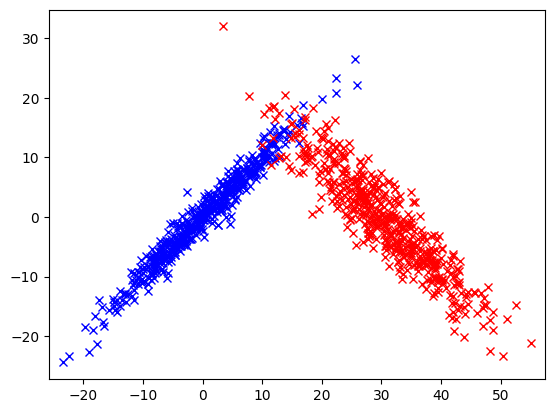

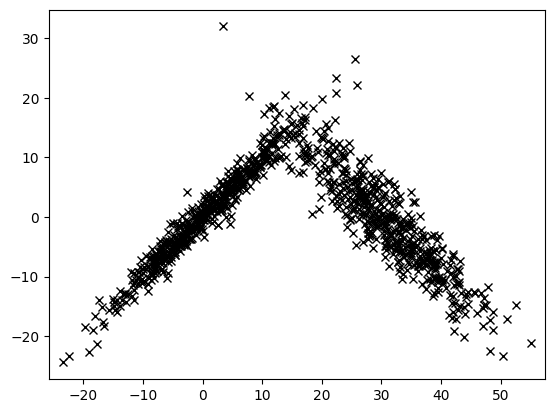

In [83]:
#import numpy as np
#import matplotlib.pyplot as plt
m1 = [0,0]
c1 = [[100,100],[-3,-5]]
x1, y1 = np.random.multivariate_normal(m1, c1, 500).T
m2 = [30,0]
c2 = [[-100,100],[-3,-5]]
x2, y2 = np.random.multivariate_normal(m2, c2, 500).T
x = np.concatenate((np.array(x1),np.array(x2)),axis=0)
y = np.concatenate((np.array(y1),np.array(y2)),axis=0)
datos = np.column_stack((x,y))
print(datos.shape)
print(x.shape)
print(y.shape)
plt.plot(x1, y1, 'xb')
plt.plot(x2, y2, 'xr')
plt.axis('equal')
plt.show()
plt.plot(x, y, 'xk')
plt.axis('equal')
plt.show()

## Valores iniciales
En la primera iteración se inicializan los centroides y las matrices de covarianza con números aleatorios

Se debe garantizar que las matrices de covarianza sean simétricas positivas

La variable delta se usará para guardar el mayor cambio en los valores de los centroides y las covarianzas

In [84]:
ma_x = np.max(x)
mi_x = np.min(x)
ma_y = np.max(y)
mi_y = np.min(y)
mi_t = np.min([mi_x,mi_y])
ma_t = np.max([ma_x,ma_y])
xc = np.random.rand(1,2)*(ma_x-mi_x)+mi_x
yc = np.random.rand(1,2)*(ma_y-mi_y)+mi_y
c1 = np.array([xc[0][0],yc[0][0]])
c2 = np.array([xc[0][1],yc[0][1]])
cov1 = np.random.rand(2,2)*(ma_t-mi_t)+mi_t
cov1 = cov1.dot(cov1.T)
cov2 = np.random.rand(2,2)*(ma_t-mi_t)+mi_t
cov2 = cov2.dot(cov2.T)
delta = 100
print("Centroide 1 = ")
print(c1)
print("Covarianza 1")
print(cov1)
print("Centroide 2 = ")
print(c2)
print("Covarianza 2")
print(cov2)

Centroide 1 = 
[47.49926247 12.69098711]
Covarianza 1
[[3048.32514097 -962.37053061]
 [-962.37053061  368.23034034]]
Centroide 2 = 
[-23.23870359  12.88430932]
Covarianza 2
[[ 382.83495387 -858.80722328]
 [-858.80722328 2099.30094924]]


## Iteraciones siguientes
Con los datos separados en la iteración anterior, se recalculan los centroides y las matrices de covarianza

El proceso se repite hasta que no se perciban cambios significativos en los parámetros

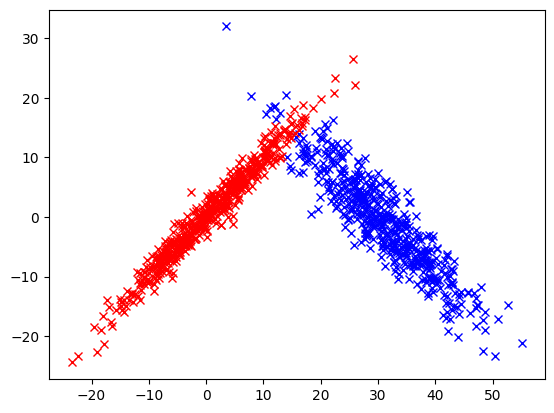

Centroide 1 = 
[29.95624089  0.05795205]
Covarianza 1
[[ 66.13643044 -59.33852587]
 [-59.33852587  64.22404454]]
Centroide 2 = 
[0.44927704 0.51018524]
Covarianza 2
[[72.76670612 72.54123564]
 [72.54123564 75.04498062]]
Delta = 
2982.188710531732


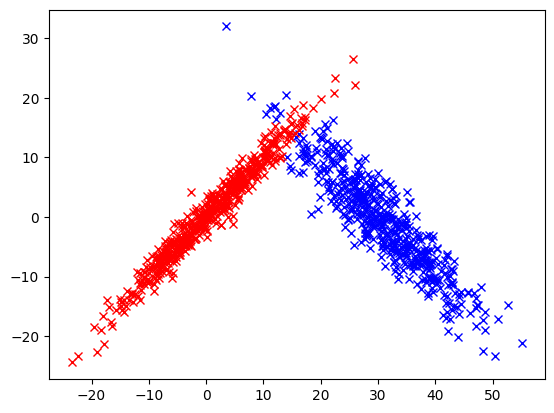

Centroide 1 = 
[30.81616223 -0.77211946]
Covarianza 1
[[ 65.64852032 -60.40603771]
 [-60.40603771  66.81382832]]
Centroide 2 = 
[0.65769744 0.7567168 ]
Covarianza 2
[[66.73239325 65.60818202]
 [65.60818202 66.96954698]]
Delta = 
8.075433638477918


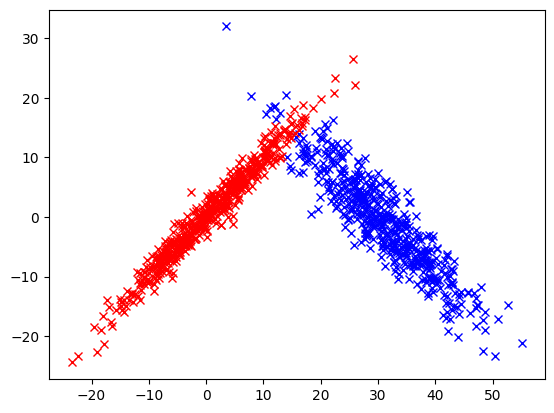

Centroide 1 = 
[30.81616223 -0.77211946]
Covarianza 1
[[ 65.64852032 -60.40603771]
 [-60.40603771  66.81382832]]
Centroide 2 = 
[0.65769744 0.7567168 ]
Covarianza 2
[[66.73239325 65.60818202]
 [65.60818202 66.96954698]]
Delta = 
0.0


In [86]:
while delta > 0.01:
  c1a = c1
  c2a = c2
  cov1a = cov1
  cov2a = cov2
  cov1 = np.cov(d1.T)
  cov2 = np.cov(d2.T)
  c1 = np.array([np.mean(d1[:,0]),np.mean(d1[:,1])])
  c2 = np.array([np.mean(d2[:,0]),np.mean(d2[:,1])])
  p1 = multivariate_normal.pdf(datos,c1, cov1)
  p2 = multivariate_normal.pdf(datos,c2, cov2)
  i1 = p1 > p2
  i2 = ~i1
  d1 = datos[i1,:]
  d2 = datos[i2,:]
  plt.plot(d1[:,0],d1[:,1], 'xb')
  plt.plot(d2[:,0],d2[:,1], 'xr')
  plt.show()
  print("Centroide 1 = ")
  print(c1)
  print("Covarianza 1")
  print(cov1)
  print("Centroide 2 = ")
  print(c2)
  print("Covarianza 2")
  print(cov2)
  delta = np.max([np.max(np.abs(cov1-cov1a)),np.max(np.abs(cov2-cov2a)),np.max(np.abs(c1-c1a)),np.max(np.abs(c2-c2a))])
  print("Delta = ")
  print(delta)